# Proyek Analisis Data: [Bike Shering Analysis]
- **Nama:** Steven Graciano Immanuel Cahyono
- **Email:** tugasstevengraciano@gmail.com
- **ID Dicoding:** Steven Graciano Immanuel Cahyono

## Menentukan Pertanyaan Bisnis

- Berapa total transaksi penyewaan sepeda selama periode 2011–2012, bagaimana proporsi antara pengguna casual dan registered terhadap total transaksi, serta segmen mana yang mendominasi dan bagaimana implikasinya terhadap strategi peningkatan penggunaan?
- Berapa tingkat pertumbuhan total penyewaan sepeda dari 2011 ke 2012, bagaimana pola fluktuasi bulanan yang terjadi, dan apa implikasinya terhadap strategi operasional?
- Musim mana dalam periode 2011–2012 yang memberikan kontribusi transaksi penyewaan sepeda terbesar, berapa persentasenya terhadap total transaksi keseluruhan, serta strategi apa yang dapat diterapkan untuk meningkatkan performa musim dengan kontribusi terendah?
- Bagaimana hubungan antara suhu dan jumlah transaksi penyewaan sepeda selama periode 2011–2012, serta pada rentang suhu berapa transaksi paling optimal terjadi?
- Hari apa yang memiliki rata-rata volume penyewaan sepeda tertinggi selama periode 2011–2012, bagaimana kontribusinya terhadap total transaksi, serta apakah terdapat perbedaan signifikan antara hari kerja dan akhir pekan?
- Pada jam berapa volume penyewaan sepeda mencapai titik tertinggi selama periode 2011–2012, bagaimana pola distribusi transaksi sepanjang hari?
- Bagaimana pengaruh kondisi cuaca terhadap volume penyewaan sepeda selama periode 2011–2012, serta kondisi cuaca mana yang menghasilkan total transaksi tertinggi dan terendah?

## Import Semua Packages/Library yang Digunakan

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates

## Data Wrangling

### Gathering Data

In [23]:
df = pd.read_csv("data\hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



## **Insight**

Dataset terdiri dari **17 kolom** dengan mayoritas bertipe numerik. Namun, beberapa kolom numerik sebenarnya merupakan representasi kategori sehingga perlu dilakukan *mapping* sebelum analisis.

Fitur dalam dataset mencakup:

* **Waktu & kalender**: `dteday`, `yr`, `mnth`, `hr`, `weekday`
* **Musiman & hari khusus**: `season`, `holiday`, `workingday`
* **Kondisi cuaca & lingkungan**: `weathersit`, `temp`, `atemp`, `hum`, `windspeed`
* **Segmentasi & total transaksi**: `casual`, `registered`, `cnt`


### Assessing Data

In [24]:
print("Jumlah Missing Values per Kolom:", df.isnull().sum())
print("Jumlah Data Duplikat:", df.duplicated().sum())
df.info()

Jumlah Missing Values per Kolom: instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah Data Duplikat: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp      

**Insight:**

* Tidak terdapat missing value sehingga tidak diperlukan proses handling data kosong
* Tidak terdapat data duplikat sehingga tidak perlu dilakukan penghapusan data
* Terdapat tipe data yang belum sesuai, yaitu `dteday` yang masih bertipe object dan perlu dikonversi ke tipe `date`
* Perlu dilakukan perubahan nama kolom serta mapping kategori agar interpretasi lebih jelas dan tidak ambigu
* Variabel `temp`, `atemp`, `hum`, dan `windspeed` masih dalam bentuk normalisasi sehingga akan dikonversi ke nilai aktual agar lebih mudah dibaca dan dianalisis


**Penjelasan Kolom**

| No | Nama Kolom | Tipe Data | Fungsi / Deskripsi                               | Jumlah Null |
| -- | ---------- | --------- | ------------------------------------------------ | ----------- |
| 1  | instant    | int64     | Indeks atau ID unik untuk setiap record          | 0           |
| 2  | dteday     | object    | Tanggal pencatatan data                          | 0           |
| 3  | season     | int64     | Musim (1: Spring, 2: Summer, 3: Fall, 4: Winter) | 0           |
| 4  | yr         | int64     | Tahun (0: 2011, 1: 2012)                         | 0           |
| 5  | mnth       | int64     | Bulan (1–12)                                     | 0           |
| 6  | hr         | int64     | Jam (0–23)                                       | 0           |
| 7  | holiday    | int64     | Status hari libur (1: Libur, 0: Bukan libur)     | 0           |
| 8  | weekday    | int64     | Hari dalam seminggu                              | 0           |
| 9  | workingday | int64     | Hari kerja (1: Ya, 0: Weekend/libur)             | 0           |
| 10 | weathersit | int64     | Kondisi cuaca (1–4, kategori cuaca)              | 0           |
| 11 | temp       | float64   | Suhu normalisasi (dibagi 41)                     | 0           |
| 12 | atemp      | float64   | Suhu terasa normalisasi (dibagi 50)              | 0           |
| 13 | hum        | float64   | Kelembaban normalisasi (dibagi 100)              | 0           |
| 14 | windspeed  | float64   | Kecepatan angin normalisasi (dibagi 67)          | 0           |
| 15 | casual     | int64     | Jumlah pengguna casual                           | 0           |
| 16 | registered | int64     | Jumlah pengguna terdaftar                        | 0           |
| 17 | cnt        | int64     | Total penyewaan sepeda (casual + registered)     | 0           |

---

**🔎 Detail Kategori Cuaca (weathersit)**

| Kode | Keterangan                              |
| ---- | --------------------------------------- |
| 1    | Cerah / Sedikit berawan / Partly cloudy |
| 2    | Berkabut + Berawan                      |
| 3    | Hujan ringan / Salju ringan             |
| 4    | Hujan lebat / Badai / Salju + Kabut     |

---

**Yang Perlu diubah dan di-mapping**

1. `instant` → `id` agar tidak ambigu

2. `dteday` → ubah tipe data ke `date`

3. `season` → mapping
   1: Spring, 2: Summer, 3: Fall, 4: Winter

4. `yr` → mapping
   0: 2011, 1: 2012

5. `holiday` → mapping
   0: Tidak Libur, 1: Libur

6. `weekday` → mapping
   0: Minggu, 1: Senin, 2: Selasa, 3: Rabu, 4: Kamis, 5: Jumat, 6: Sabtu

7. `weathersit` → mapping
   1: Cerah/Partly Cloudy
   2: Berkabut/Berawan
   3: Hujan/Salju Ringan
   4: Hujan Lebat/Badai/Salju + Kabut

8. `temp` → convert ke suhu asli (°C) dengan mengalikan 41

9. `atemp` → convert ke suhu terasa asli (°C) dengan mengalikan 50

10. `hum` → convert ke persentase kelembapan asli (%) dengan mengalikan 100

11. `windspeed` → convert ke kecepatan angin asli (km/jam) dengan mengalikan 67


### Cleaning Data

In [25]:
import pandas as pd

def clean_bike_data(df):
    df_clean = df.copy()
    
    # Rename column
    df_clean = df_clean.rename(columns={
        "instant": "id"
    })
    
    # Convert date
    df_clean["dteday"] = pd.to_datetime(df_clean["dteday"])
    
    # Mapping kategori
    df_clean["season"] = df_clean["season"].map({
        1: "Semi",
        2: "Panas",
        3: "Gugur",
        4: "Dingin"
    })
    
    df_clean["yr"] = df_clean["yr"].map({
        0: 2011,
        1: 2012
    })
    
    df_clean["holiday"] = df_clean["holiday"].map({
        0: "Tidak Libur",
        1: "Libur"
    })
    
    df_clean["weekday"] = df_clean["weekday"].map({
        0: "Minggu",
        1: "Senin",
        2: "Selasa",
        3: "Rabu",
        4: "Kamis",
        5: "Jumat",
        6: "Sabtu"
    })
    
    df_clean["weathersit"] = df_clean["weathersit"].map({
        1: "Cerah/Partly Cloudy",
        2: "Berkabut/Berawan",
        3: "Hujan/Salju Ringan",
        4: "Hujan Lebat/Badai/Salju + Kabut"
    })
    
    # Convert ke nilai asli
    df_clean["temp"] = (df_clean["temp"] * 41).round(2)
    df_clean["atemp"] = (df_clean["atemp"] * 50).round(2)
    df_clean["hum"] = (df_clean["hum"] * 100).round(2)
    df_clean["windspeed"] = (df_clean["windspeed"] * 67).round(2)
    
    return df_clean


# Apply function
df_clean = clean_bike_data(df)

In [26]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  object        
 7   weekday     17379 non-null  object        
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [27]:
df_clean.head().T

,0,1,2,3,4
id,1,2,3,4,5
dteday,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-01-01 00:00:00
season,Semi,Semi,Semi,Semi,Semi
yr,2011,2011,2011,2011,2011
mnth,1,1,1,1,1
hr,0,1,2,3,4
holiday,Tidak Libur,Tidak Libur,Tidak Libur,Tidak Libur,Tidak Libur
weekday,Sabtu,Sabtu,Sabtu,Sabtu,Sabtu
workingday,0,0,0,0,0
weathersit,Cerah/Partly Cloudy,Cerah/Partly Cloudy,Cerah/Partly Cloudy,Cerah/Partly Cloudy,Cerah/Partly Cloudy


**Insight:**

* Dataset sudah bebas ambiguitas karena `instant` diganti jadi `id` (jelas sebagai unique identifier).

* `dteday` sudah dalam format datetime → siap dipakai untuk analisis time-series, tren bulanan, musiman, dll.

* Semua fitur kategorikal (`season`, `weekday`, `holiday`, `weathersit`, `yr`) sudah di-mapping ke label yang readable → visualisasi & interpretasi jadi lebih gampang.

* Variabel cuaca (`temp`, `atemp`, `hum`, `windspeed`) sudah dikonversi ke nilai asli (°C, %, km/jam) → analisis korelasi ke `cnt` jadi lebih meaningful secara bisnis.

* Mengurangi risiko salah interpretasi karena tidak lagi menggunakan nilai normalisasi.

* Dataset sudah siap di proses untuk EDA


## Exploratory Data Analysis (EDA)

### Explore ...

In [28]:
df_clean.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,17379.0,NaN,NaN,NaN,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,NaN,NaN,NaN,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379,4,Gugur,4496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yr,17379.0,NaN,NaN,NaN,2011.502561,2011.0,2011.0,2012.0,2012.0,2012.0,0.500008
mnth,17379.0,NaN,NaN,NaN,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,NaN,NaN,NaN,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379,2,Tidak Libur,16879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday,17379,7,Sabtu,2512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workingday,17379.0,NaN,NaN,NaN,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379,4,Cerah/Partly Cloudy,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Ambil hanya kolom numerik
df_numeric = df_clean.select_dtypes(include=["int64", "float64"])

# Hitung correlation matrix
corr_matrix = df_numeric.corr()

# Ambil korelasi terhadap 'cnt', urutkan dari besar ke kecil
corr_with_cnt = corr_matrix["cnt"].sort_values(ascending=False)

print("Korelasi terhadap 'cnt' (urut dari terbesar ke terkecil):\n")
print(corr_with_cnt)

Korelasi terhadap 'cnt' (urut dari terbesar ke terkecil):

cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400925
hr            0.394071
id            0.278379
yr            0.250495
mnth          0.120638
windspeed     0.093239
workingday    0.030284
hum          -0.322911
Name: cnt, dtype: float64


In [30]:
# ===============================
# 1. Total Transaksi Penyewaan Sepeda
# ===============================
total_transaksi = df_clean["cnt"].sum()
print("1. Total Transaksi Penyewaan Sepeda:", total_transaksi)

print('---------------------------')

# ===============================
# 2. Demografi Penyewa Sepeda
# ===============================
print("2. Demografi Penyewa Sepeda:")
total_registered = df_clean["registered"].sum()
total_casual = df_clean["casual"].sum()

print(f"Registered/Terdaftar: {total_registered} ({total_registered/total_transaksi:.2%})")
print(f"Casual/Tidak Terdaftar: {total_casual} ({total_casual/total_transaksi:.2%})")

print('---------------------------')

# ===============================
# 3. Jumlah Transaksi per Tahun
# ===============================
print("3. Jumlah Transaksi Penyewaan Sepeda per Tahun:")

year_counts = df_clean.groupby("yr")["cnt"].sum()

print(f"Tahun 2011: {year_counts[2011]} ({year_counts[2011]/total_transaksi:.2%})")
print(f"Tahun 2012: {year_counts[2012]} ({year_counts[2012]/total_transaksi:.2%})")

yoy = (year_counts[2012] - year_counts[2011]) / year_counts[2011]
print(f"\nYoY Growth 2012 vs 2011: {yoy:.2%}")

print('---------------------------')

# ===============================
# 4. Musim dengan Penyewaan Terbanyak
# ===============================
print("4. Musim dengan Penyewaan Sepeda Terbanyak:")

season_counts = df_clean.groupby("season")["cnt"].sum().sort_values(ascending=False)

for season, value in season_counts.items():
    print(f"{season}: {value} ({value/total_transaksi:.2%})")

print('---------------------------')

# ===============================
# 5. Hari dengan Penyewaan Terbanyak
# ===============================
print("5. Hari dalam seminggu dengan Penyewaan Terbanyak:")

weekday_counts = df_clean.groupby("weekday")["cnt"].sum().sort_values(ascending=False)
for day, value in weekday_counts.items():
    print(f"{day}: {value} ({value/total_transaksi:.2%})")

print('---------------------------')

# ===============================
# 6. Peak Hour (Top 5 Jam)
# ===============================
print("6. Jam Penyewaan Sepeda Terbanyak (Top 5):")

hour_counts = (
    df_clean.groupby("hr")["cnt"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

for hour, value in hour_counts.items():
    print(f"Jam {hour}: {value} ({value/total_transaksi:.2%})")

print('---------------------------')

# ===============================
# 7. Pengaruh Cuaca
# ===============================
print("7. Pengaruh Cuaca terhadap Penyewaan Sepeda:")

weather_counts = df_clean.groupby("weathersit")["cnt"].sum().sort_values(ascending=False)

for weather, value in weather_counts.items():
    print(f"{weather}: {value} ({value/total_transaksi:.2%})")

1. Total Transaksi Penyewaan Sepeda: 3292679
---------------------------
2. Demografi Penyewa Sepeda:
Registered/Terdaftar: 2672662 (81.17%)
Casual/Tidak Terdaftar: 620017 (18.83%)
---------------------------
3. Jumlah Transaksi Penyewaan Sepeda per Tahun:
Tahun 2011: 1243103 (37.75%)
Tahun 2012: 2049576 (62.25%)

YoY Growth 2012 vs 2011: 64.88%
---------------------------
4. Musim dengan Penyewaan Sepeda Terbanyak:
Gugur: 1061129 (32.23%)
Panas: 918589 (27.90%)
Dingin: 841613 (25.56%)
Semi: 471348 (14.32%)
---------------------------
5. Hari dalam seminggu dengan Penyewaan Terbanyak:
Jumat: 487790 (14.81%)
Kamis: 485395 (14.74%)
Sabtu: 477807 (14.51%)
Rabu: 473048 (14.37%)
Selasa: 469109 (14.25%)
Senin: 455503 (13.83%)
Minggu: 444027 (13.49%)
---------------------------
6. Jam Penyewaan Sepeda Terbanyak (Top 5):
Jam 17: 336860 (10.23%)
Jam 18: 309772 (9.41%)
Jam 8: 261001 (7.93%)
Jam 16: 227748 (6.92%)
Jam 19: 226789 (6.89%)
---------------------------
7. Pengaruh Cuaca terhadap Penye

**Insigth** : 

* Total transaksi penyewaan sepeda: 3.292.679

  * Menunjukkan volume penggunaan yang tinggi dalam dua tahun pengamatan
  * Data cukup representatif untuk melihat pola musiman, tahunan, dan pengaruh cuaca

* Komposisi penyewa

  * Registered: 2.672.662 (81,17%)
  * Casual: 620.017 (18,83%)
  * Korelasi ke `cnt`

    * `registered` (0,97) sangat kuat karena merupakan komponen utama pembentuk total
    * `casual` (0,69) juga kuat karena bagian langsung dari total
  * Implikasi

    * Sistem lebih banyak digunakan oleh pengguna tetap
    * Stabilitas demand kemungkinan besar ditopang oleh registered user

* Transaksi per tahun

  * 2011: 1.243.103 (37,75%)
  * 2012: 2.049.576 (62,25%)
  * YoY growth 2012 vs 2011: 64,88%
  * Korelasi `yr` (0,25) menunjukkan tren kenaikan moderat
  * Implikasi

    * Ada pertumbuhan signifikan antar tahun
    * Bisa dipengaruhi ekspansi layanan, peningkatan awareness, atau pertumbuhan registered user

* Musim

  * Gugur: 32,23% (tertinggi)
  * Panas: 27,90%
  * Dingin: 25,56%
  * Semi: 14,32% (terendah)
  * Selaras dengan korelasi `temp` (0,40) dan `atemp` (0,40)

    * Suhu yang lebih nyaman meningkatkan minat bersepeda
  * Implikasi

    * Permintaan optimal terjadi pada suhu tidak terlalu ekstrem
    * Semi yang relatif lebih dingin atau transisi musim memiliki demand lebih rendah

* Hari dalam seminggu

  * Distribusi relatif merata (sekitar 14% tiap hari)
  * Jumat tertinggi, tetapi selisih tidak signifikan
  * `workingday` (0,03) menunjukkan pengaruh linear sangat kecil
  * Implikasi

    * Perbedaan weekday dan weekend tidak terlalu kuat secara agregat
    * Pola kemungkinan lebih terlihat pada level jam (commuting hours)

* Kondisi cuaca

  * Cerah/Partly Cloudy: 71,01% (dominan)
  * Berkabut/Berawan: 24,17%
  * Hujan/Salju Ringan: 4,81%
  * Hujan Lebat/Badai/Salju + Kabut: 0,01%
  * Korelasi mendukung

    * `temp` positif (0,40)
    * `hum` negatif (-0,32)
    * `windspeed` rendah (0,09)
  * Implikasi

    * Cuaca nyaman meningkatkan volume
    * Kelembapan tinggi menurunkan minat
    * Kecepatan angin tidak terlalu signifikan secara linear

* Faktor waktu dan suhu sebagai driver utama eksternal

  * `hr` (0,39) menunjukkan pengaruh moderat
  * Kombinasi jam tertentu dan suhu nyaman menjadi pendorong utama peningkatan `cnt`
  * Di luar komponen langsung (`registered` dan `casual`), variabel paling relevan adalah waktu dan suhu


## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total transaksi penyewaan sepeda selama periode 2011–2012, bagaimana proporsi antara pengguna casual dan registered terhadap total transaksi, serta segmen mana yang mendominasi dan bagaimana implikasinya terhadap strategi peningkatan penggunaan?

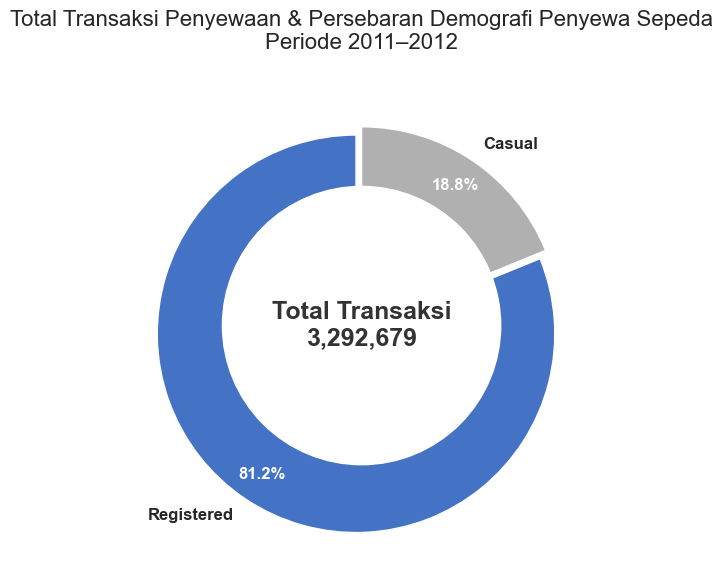

In [31]:
# ── 1. Hitung Data ────────────────────────────────────────────────────────────
total_transaksi  = df_clean["cnt"].sum()
total_registered = df_clean["registered"].sum()
total_casual     = df_clean["casual"].sum()

pct_registered = total_registered / total_transaksi
pct_casual     = total_casual     / total_transaksi

labels  = ["Registered", "Casual"]
sizes   = [total_registered, total_casual]
colors  = ["#4472C4", "#b0b0b0"]
explode = (0.05, 0)

fig, ax = plt.subplots(figsize=(20, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=explode,
    textprops={"fontsize": 12, "fontweight": "bold"},
)
plt.setp(autotexts, size=12, color="white")

# Lubang tengah
ax.add_artist(plt.Circle((0, 0), 0.70, fc="white"))

ax.text(0, 0, f"Total Transaksi\n{total_transaksi:,}",
        ha="center", va="center", fontsize=18, fontweight="bold", color="#333333")

ax.set_title(
    "Total Transaksi Penyewaan & Persebaran Demografi Penyewa Sepeda\n"
    "Periode 2011–2012",
    fontsize=16, pad=20
)
plt.tight_layout()
plt.show()

* **Total transaksi: 3.292.679**

  * 81% registered (2.672.662 transaksi)
  * 18,8% casual (620.017 transaksi)
  * _Struktur ini menunjukkan bisnis sangat bergantung pada member tetap_

* **Analisis**

  * Dominasi registered

    * Revenue dan stabilitas demand kemungkinan besar ditopang oleh member
    * Risiko bisnis rendah karena ada basis pengguna loyal
    * Fokus utama: retensi, bukan akuisisi ulang

  * Porsi casual cukup signifikan

    * Hampir 1 dari 5 transaksi berasal dari non-member
    * Ini adalah pool konversi potensial
    * Artinya peluang growth terbesar ada di konversi casual → registered

  * Strategi pertumbuhan realistis

    * Bukan menaikkan frekuensi member (sudah tinggi)
    * Tapi meningkatkan conversion rate dari casual

* **Rekomendasi**
  * ``Untuk Registered (Retention Strategy)``

    * Loyalty benefit tambahan (misal free ride setelah X trip)
    * Early access promo musiman
    * Reminder otomatis saat frekuensi turun
    * Paket membership tahunan dengan harga lebih hemat

  * `Untuk Casual (Conversion Strategy)`

    * Promo trial membership 7–14 hari
    * Diskon upgrade setelah 3–5 kali transaksi
    * Tampilkan perbandingan biaya casual vs member di aplikasi

      * “Kalau kamu jadi member, bulan ini bisa hemat X%”
    * Bundling membership + bonus saldo ride

* **Kesimpulan** 

  * Member = aset utama, harus dijaga
  * Casual = sumber pertumbuhan
  * Fokus bisnis: retensi tinggi + konversi agresif namun terukur


### Pertanyaan 2: Berapa tingkat pertumbuhan total penyewaan sepeda dari 2011 ke 2012, bagaimana pola fluktuasi bulanan yang terjadi, dan apa implikasinya terhadap strategi operasional?


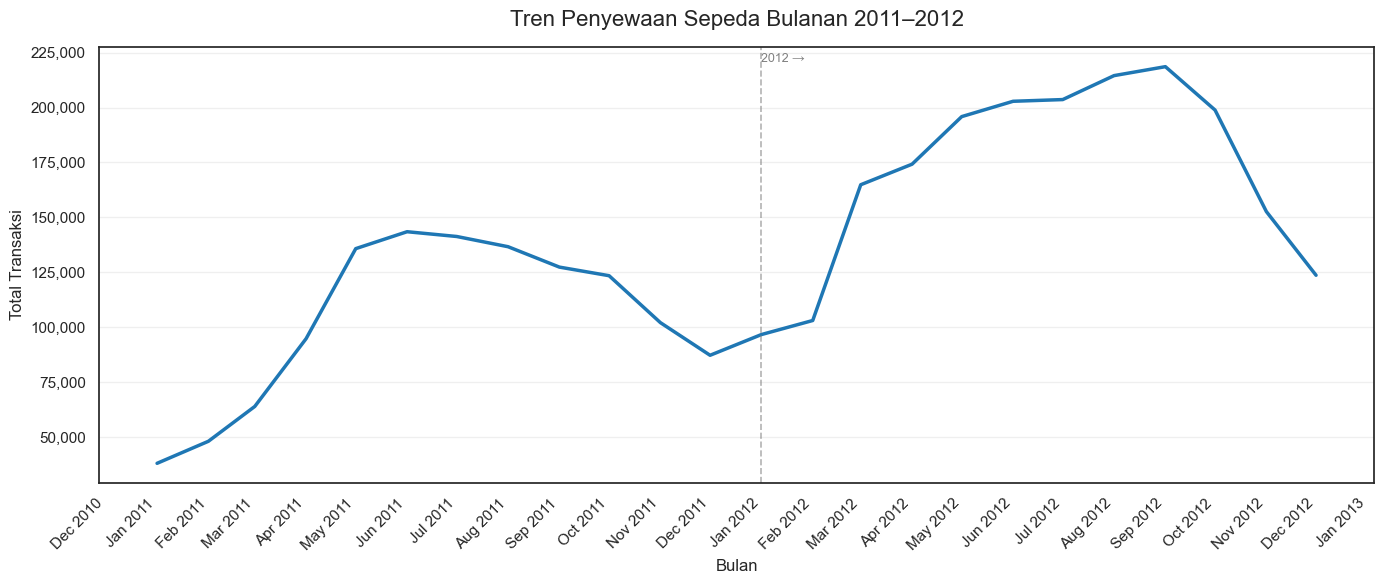

In [32]:
# ── 1. Agregasi per Bulan ─────────────────────────────────────────────────────
df_clean["month"] = pd.to_datetime(df_clean["dteday"]).dt.to_period("M")

monthly = (
    df_clean
    .groupby("month")
    .agg(cnt=("cnt", "sum"))
    .reset_index()
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

# ── 2. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly["month_dt"], monthly["cnt"], color="#1f77b4", linewidth=2.5)

# Garis pemisah tahun
ax.axvline(pd.Timestamp("2012-01-01"), color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(pd.Timestamp("2012-01-01"), monthly["cnt"].max() * 1.01, "2012 →", fontsize=9, color="gray")

# ── 3. Styling ────────────────────────────────────────────────────────────────
ax.set_title("Tren Penyewaan Sepeda Bulanan 2011–2012", fontsize=16, pad=15)
ax.set_xlabel("Bulan", fontsize=12)
ax.set_ylabel("Total Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* **Insight Utama**

  * Penyewaan tertinggi terjadi pada Oktober 2012
  * Terendah terjadi pada Januari 2011
  * Tren mulai naik sejak Maret dan turun setelah Oktober
  * **Pola ini mengikuti musim: naik saat cuaca hangat, turun saat musim dingin**

* **Analisis**

  * **Demand sangat dipengaruhi musim**
  * Spring hingga Fall adalah periode kuat
  * Winter adalah periode lemah
  * Pola ini konsisten sehingga bisa diprediksi dan direncanakan

* **Rekomendasi**
* `Saat Maret–Oktober (High Season)`

    * Fokus tingkatkan transaksi

      * Periode ini adalah fase demand alami meningkat karena cuaca lebih nyaman
      * Target utama adalah memaksimalkan jumlah ride sebanyak mungkin
      * Optimalkan ketersediaan sepeda dan pastikan tidak ada lost demand saat peak

    * Dorong casual jadi member sebelum masuk peak

      * Lakukan promosi upgrade di awal Spring (Maret–April)
      * Arahkan casual user yang mulai sering menggunakan sepeda untuk beralih ke membership
      * Gunakan pendekatan penghematan biaya agar mereka melihat benefit jangka panjang

    * Maksimalkan promo upgrade membership

      * Berikan diskon khusus upgrade sebelum September–Oktober
      * Tawarkan bonus seperti tambahan durasi ride atau potongan harga bulan pertama
      * Tujuannya agar saat periode peak tiba, lebih banyak pengguna sudah menjadi member tetap

  * `Saat November–Februari (Low Season)`

    * Jaga agar member tetap aktif

      * Fokus pada engagement agar mereka tidak berhenti menggunakan layanan
      * Berikan notifikasi personal atau reminder penggunaan
      * Buat program sederhana seperti reward untuk jumlah ride tertentu

    * Berikan diskon perpanjangan membership

      * Tawarkan potongan harga untuk perpanjangan di musim dingin
      * Bisa juga diberikan tambahan masa aktif jika memperpanjang lebih awal
      * Tujuannya menjaga revenue tetap stabil walau frekuensi turun

    * Buat promo ringan agar volume tidak turun drastis

      * Diskon khusus musim dingin
      * Paket harga hemat untuk periode tertentu
      * Strategi ini tidak harus agresif, cukup untuk menahan penurunan tajam
  

* **Kesimpulan**

  * Gunakan high season untuk growth
  * Gunakan low season untuk stabilitas
  * Fokus konversi casual saat tren mulai naik dan jaga loyalitas member saat tren turun

### Pertanyaan 3: Musim mana dalam periode 2011–2012 yang memberikan kontribusi transaksi penyewaan sepeda terbesar, berapa persentasenya terhadap total transaksi keseluruhan, serta strategi apa yang dapat diterapkan untuk meningkatkan performa musim dengan kontribusi terendah?

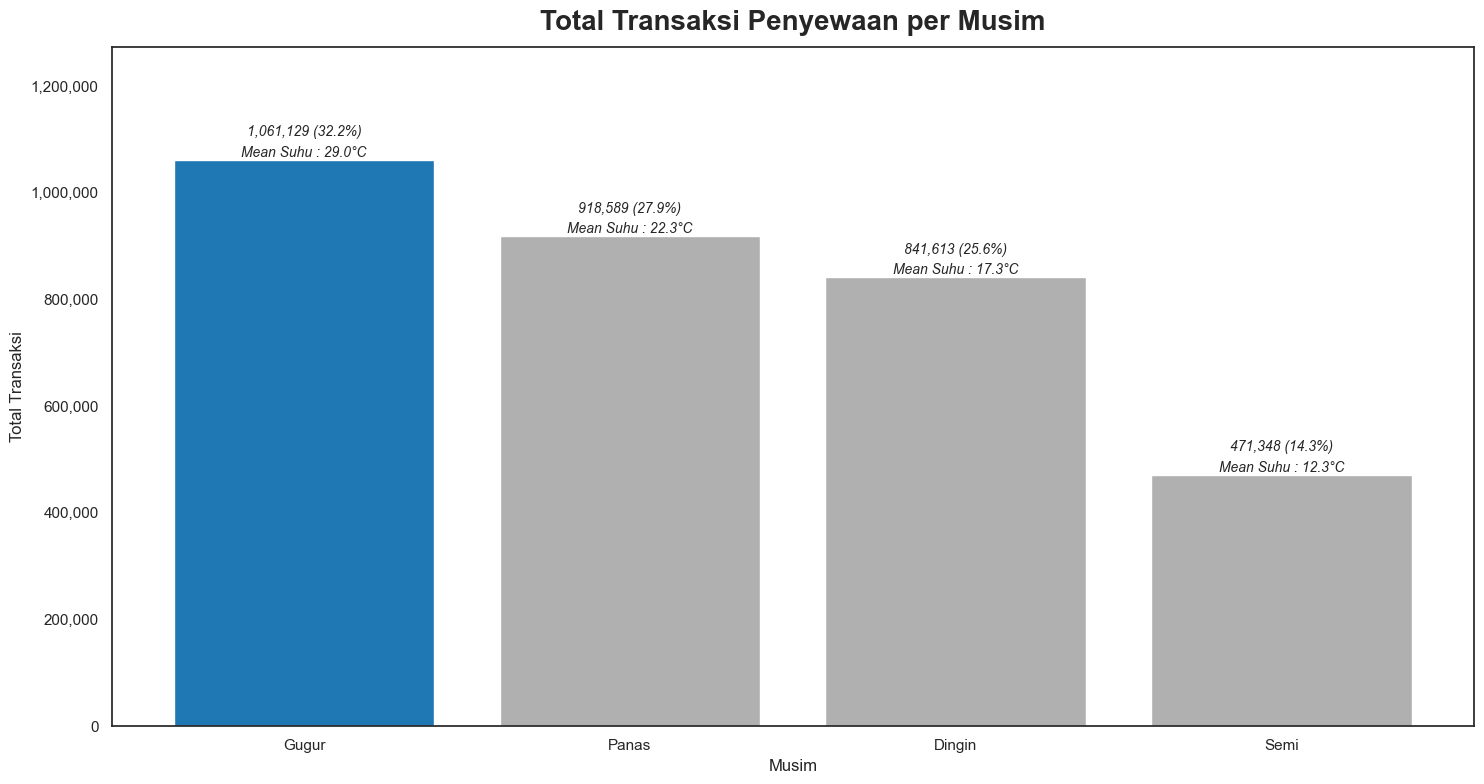

In [33]:
season_data = (
    df_clean
    .groupby("season")
    .agg(cnt=("cnt", "sum"), temp=("temp", "mean"))
    .reset_index()
    .sort_values("cnt", ascending=False)
    .reset_index(drop=True)   # index bersih 0,1,2,... untuk posisi bar
)

total_transaksi = df_clean["cnt"].sum()

BAR_HIGHLIGHT = "#1f77b4"
BAR_DEFAULT   = "#b0b0b0"

colors = [BAR_HIGHLIGHT] + [BAR_DEFAULT] * (len(season_data) - 1)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(15, 8))

ax.bar(season_data["season"], season_data["cnt"], color=colors)

for idx, row in season_data.iterrows():
    mean_suhu = row["temp"]

    label = (
        f"{row['cnt']:,} "
        f"({row['cnt'] / total_transaksi:.1%})\n"
        f"Mean Suhu : {mean_suhu:.1f}°C"  # ← label yang diminta
    )

    ax.text(
        idx,
        row["cnt"],
        label,
        ha="center",
        va="bottom",
        fontweight="normal",
        fontstyle="italic",
        fontsize=10,
        linespacing=1.6,
    )

ax.set_title("Total Transaksi Penyewaan per Musim", fontsize=20, pad=12, fontweight="bold")
ax.set_xlabel("Musim", fontsize=12)
ax.set_ylabel("Total Transaksi", fontsize=12)
ax.grid(False)
ax.set_ylim(0, season_data["cnt"].max() * 1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

**Insight**

* Total transaksi tertinggi terjadi pada musim Gugur (1.061.129 | 32,2%) dengan rata-rata suhu 29°C
* Musim Panas menyumbang 918.589 transaksi (27,9%) dengan suhu rata-rata 22,3°C
* Musim Dingin mencatat 841.613 transaksi (25,6%) dengan suhu rata-rata 17,3°C
* Musim Semi merupakan yang terendah yaitu 471.348 transaksi (14,3%) dengan suhu rata-rata 12,3°C
* Terdapat pola bahwa semakin hangat suhu, semakin tinggi jumlah penyewaan

**Analisis**

* Pola transaksi dipengaruhi kuat oleh musim dan suhu
* Musim hangat menjadi periode dengan demand tertinggi
* Musim Semi menjadi titik terlemah sehingga berpotensi untuk ditingkatkan
* Pola ini konsisten sehingga bisa dijadikan dasar perencanaan strategi tahunan

**Rekomendasi**

* Optimalkan musim Gugur dan Panas sebagai fase pertumbuhan

  * Pada saat musim ini kita perlu **Maksimalkan** operasional dan **ketersediaan sepeda**
  * Dorong konversi casual menjadi member sebelum dan saat peak season
  * Tingkatkan kampanye pemasaran untuk memaksimalkan volume transaksi

* Perkuat musim Dingin agar penurunan tidak terlalu tajam

  * Fokus pada retensi member
  * Berikan promo ringan agar aktivitas tetap berjalan

* Tingkatkan performa musim Semi

  * Berikan promo awal musim untuk menarik pengguna baru
  * Tawarkan diskon membership agar pengguna masuk sebelum musim tinggi

**Kesimpulan**

* Penyewaan sepeda memiliki pola musiman yang jelas
* Musim hangat menjadi driver utama transaksi
* Strategi terbaik adalah memaksimalkan high season dan menjaga stabilitas di low season agar revenue tetap optimal sepanjang tahun

### Pertanyaan 4 : Bagaimana hubungan antara suhu dan jumlah transaksi penyewaan sepeda selama periode 2011–2012, serta pada rentang suhu berapa transaksi paling optimal terjadi?

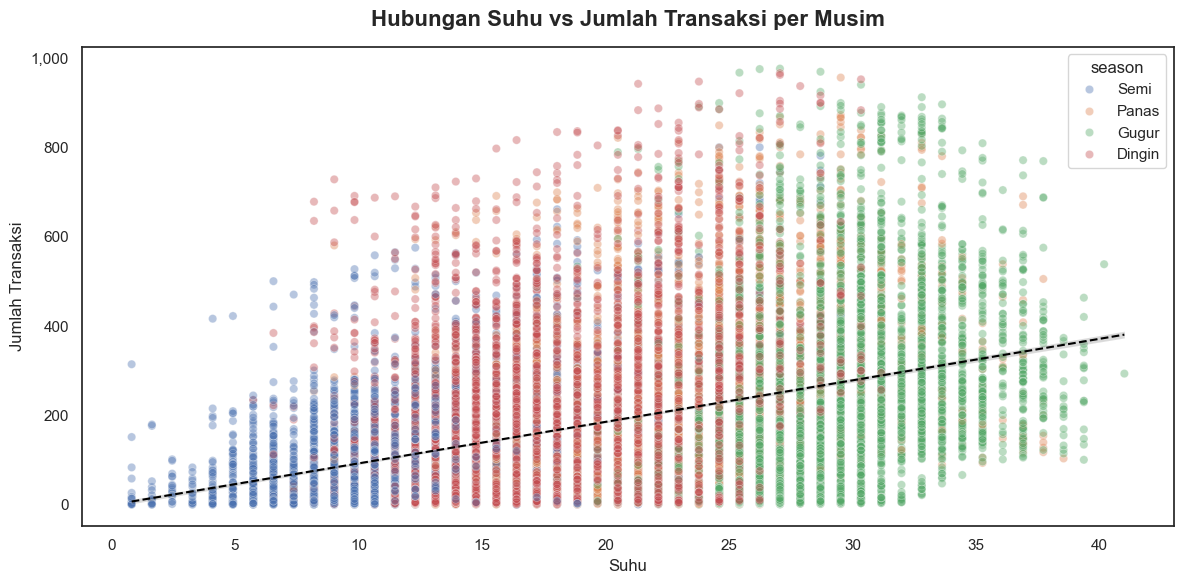

In [34]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_clean,
    x="temp",
    y="cnt",
    hue="season",
    alpha=0.4,
    ax=ax
)

# Garis tren keseluruhan
sns.regplot(
    data=df_clean,
    x="temp",
    y="cnt",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--"},
    ax=ax
)

ax.set_title("Hubungan Suhu vs Jumlah Transaksi per Musim", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Suhu", fontsize=12)
ax.set_ylabel("Jumlah Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

**Insight**

- Sesuai dengan analisis sebelumnya, suhu dan musim memiliki pengaruh terhadap jumlah transaksi penyewaan sepeda. Scatterplot menunjukkan adanya hubungan positif antara suhu dan total transaksi, dengan nilai korelasi sebesar 0,40.

- Nilai ini mengindikasikan hubungan positif sedang, yang berarti ketika suhu meningkat dan cuaca menjadi lebih hangat, jumlah penyewaan sepeda cenderung ikut meningkat.

- Hal ini juga dapat dilihat pada chart, di mana tren penyewaan mulai naik secara linear ketika suhu berada di sekitar 15°C. Setelah melewati titik tersebut, jumlah transaksi terus meningkat seiring kenaikan suhu. Semakin hangat suhu, semakin banyak pelanggan yang melakukan penyewaan.

- Ini menunjukkan bahwa suhu yang lebih nyaman menjadi faktor pendorong utama dalam meningkatkan aktivitas penyewaan sepeda.


### Pertanyaan 5 : Hari apa yang memiliki rata-rata volume penyewaan sepeda tertinggi selama periode 2011–2012, bagaimana kontribusinya terhadap total transaksi, serta apakah terdapat perbedaan signifikan antara hari kerja dan akhir pekan?

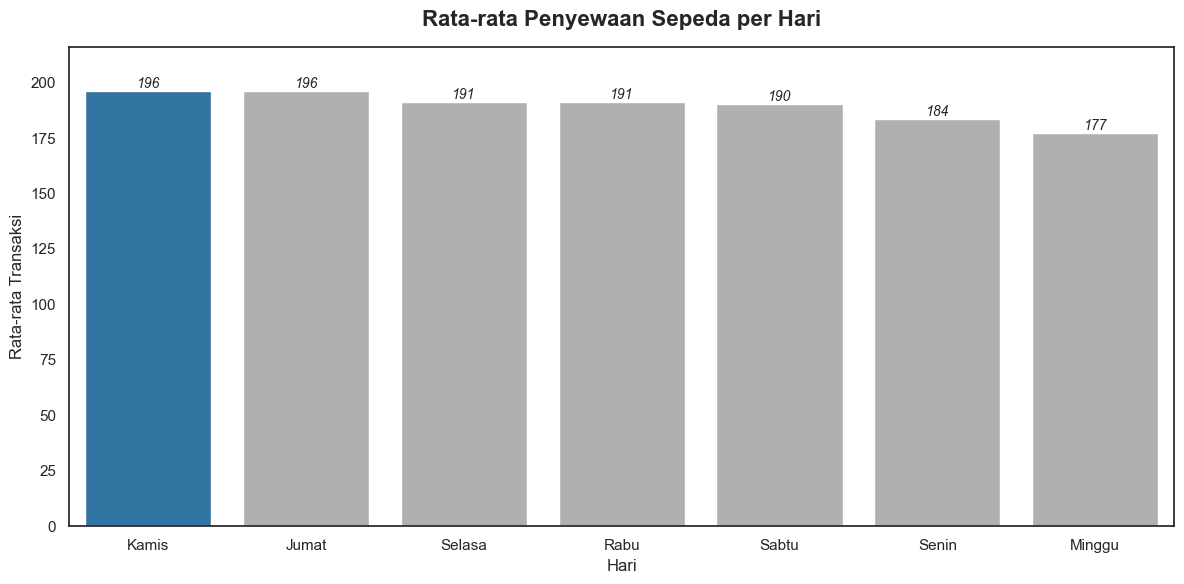

In [35]:
# ── 1. Agregasi ───────────────────────────────────────────────────────────────
weekday_data = (
    df_clean
    .groupby("weekday")
    .agg(mean_cnt=("cnt", "mean"))
    .reset_index()
    .sort_values("mean_cnt", ascending=False)
    .reset_index(drop=True)
)

# ── 2. Warna ──────────────────────────────────────────────────────────────────
weekday_data["color"] = ["#1f77b4"] + ["#b0b0b0"] * (len(weekday_data) - 1)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=weekday_data, x="weekday", y="mean_cnt", palette=weekday_data["color"].tolist(), ax=ax, hue="weekday", dodge=False)

# Label di atas bar
for idx, row in weekday_data.iterrows():
    ax.text(idx, row["mean_cnt"], f"{row['mean_cnt']:,.0f}",
            ha="center", va="bottom", fontsize=10, fontstyle="italic")

ax.set_title("Rata-rata Penyewaan Sepeda per Hari", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Hari", fontsize=12)
ax.set_ylabel("Rata-rata Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, weekday_data["mean_cnt"].max() * 1.1)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insight**

* Rata-rata penyewaan tertinggi terjadi pada Kamis dan Jumat (196 transaksi per hari)
* Selasa dan Rabu berada di angka 191 transaksi
* Sabtu sedikit turun di 190 transaksi
* Senin berada di 184 transaksi
* Minggu menjadi yang terendah dengan 177 transaksi

**Analisis**

* Aktivitas penyewaan cenderung tinggi pada hari kerja, terutama menjelang akhir pekan
* Kamis dan Jumat kemungkinan menjadi peak karena mobilitas kerja, commuting, atau aktivitas luar ruangan meningkat
* Akhir pekan justru mengalami penurunan, terutama Minggu
* Pola ini menunjukkan bahwa sepeda lebih banyak digunakan untuk kebutuhan rutin (transportasi harian) dibanding rekreasi

**Rekomendasi**

* Optimalkan Kamis–Jumat

  * Pastikan ketersediaan sepeda maksimal
  * Gunakan promo upselling membership di hari dengan traffic tinggi

* Tingkatkan performa akhir pekan

  * Buat promo khusus Sabtu–Minggu
  * Tawarkan paket family atau promo rekreasi
  * Dorong penggunaan untuk aktivitas santai atau wisata

**Kesimpulan**

* Penyewaan lebih kuat di hari kerja dibanding akhir pekan
* Pola ini mengindikasikan penggunaan dominan untuk kebutuhan mobilitas rutin
* Strategi terbaik adalah memaksimalkan peak weekday dan mendorong pertumbuhan di weekend agar distribusi transaksi lebih seimbang


### Pertanyaan 6 : Pada jam berapa volume penyewaan sepeda mencapai titik tertinggi selama periode 2011–2012, bagaimana pola distribusi transaksi sepanjang hari?


C:\Users\tugas\AppData\Local\Temp\ipykernel_3788\3250887795.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hour_data, x="hr_label", y="mean_cnt", palette=hour_data["color"].tolist(), ax=ax)


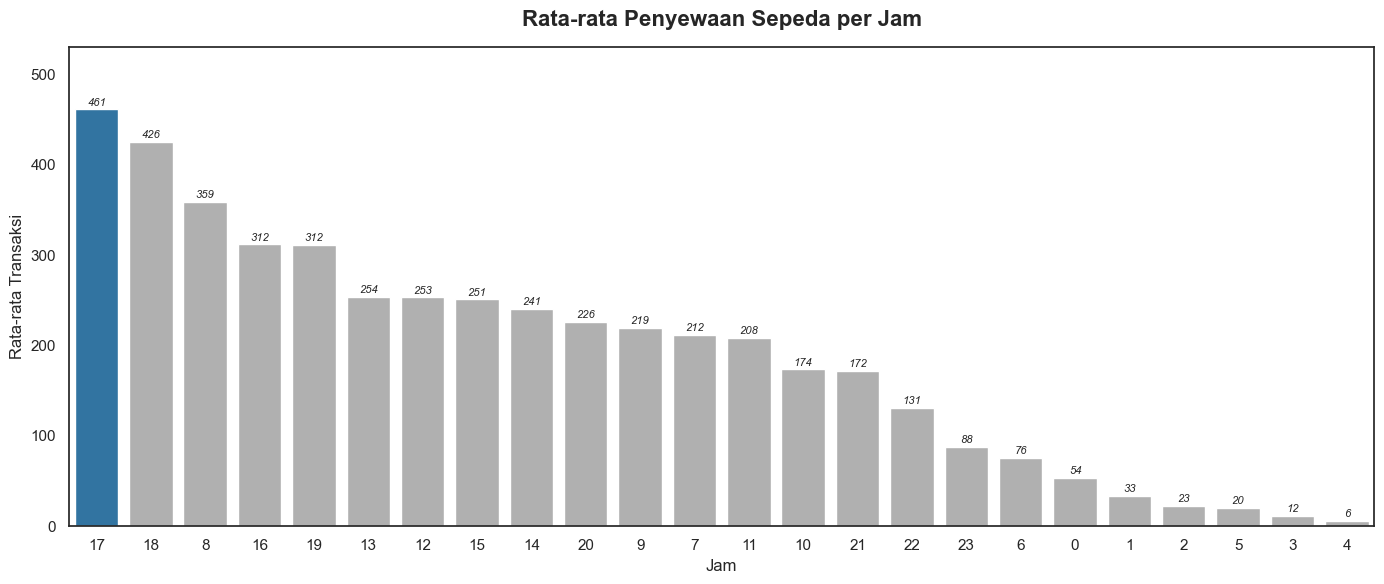

In [36]:
# ── 1. Agregasi ───────────────────────────────────────────────────────────────
hour_data = (
    df_clean
    .groupby("hr")
    .agg(mean_cnt=("cnt", "mean"))
    .reset_index()
    .sort_values("mean_cnt", ascending=False)
    .reset_index(drop=True)
)

hour_data["hr_label"] = hour_data["hr"].astype(str)  # ← fix urutan bar

# ── 2. Warna ──────────────────────────────────────────────────────────────────
hour_data["color"] = ["#1f77b4"] + ["#b0b0b0"] * (len(hour_data) - 1)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(data=hour_data, x="hr_label", y="mean_cnt", palette=hour_data["color"].tolist(), ax=ax)

# Label di atas bar
for idx, row in hour_data.iterrows():
    ax.text(idx, row["mean_cnt"] + 2, f"{row['mean_cnt']:,.0f}",
            ha="center", va="bottom", fontsize=8, fontstyle="italic")

ax.set_title("Rata-rata Penyewaan Sepeda per Jam", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Jam", fontsize=12)
ax.set_ylabel("Rata-rata Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, hour_data["mean_cnt"].max() * 1.15)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insight** (Rata-Rata)

* Puncak penyewaan terjadi pada jam 17.00 (461 transaksi) dan 18.00 (426 transaksi) 
* Jam 08.00 juga tinggi (359 transaksi)
* Pola menunjukkan dua peak utama: pagi dan sore hari
* Transaksi sangat rendah pada dini hari (00.00–05.00), bahkan hanya 6–33 transaksi
* Setelah jam 20.00, tren terus menurun

**Analisis**

* Pola ini sangat identik dengan jam kerja (commuting hours)
* Peak pagi mengindikasikan penggunaan untuk berangkat kerja atau sekolah
* Peak sore menunjukkan penggunaan untuk pulang kerja
* Rendahnya transaksi di tengah malam menandakan sepeda bukan untuk hiburan malam, tetapi lebih ke mobilitas rutin
* Data ini memperkuat indikasi bahwa sepeda lebih banyak digunakan untuk kebutuhan transportasi harian dibanding rekreasi

**Rekomendasi**

- Optimasi Operasional (Rebalancing): Pastikan ketersediaan sepeda maksimal di titik-titik pemukiman sebelum jam 08.00 dan di titik-titik perkantoran/pusat bisnis sebelum jam 17.00 untuk menghindari penumpukan atau kekosongan unit.

- Maintenance Penjadwalan: Lakukan perawatan rutin, pengecekan unit, atau pengisian daya (jika sepeda listrik) pada pukul 00.00–05.00. Ini adalah golden time karena gangguan terhadap pengguna berada pada titik terendah.

- Paket Langganan "Commuter Pass": Meluncurkan paket berlangganan bulanan atau mingguan yang memberikan diskon khusus pada jam sibuk (07.00–09.00 dan 16.00–19.00) untuk mengunci loyalitas pengguna harian.

- Kerjasama Korporat: Menjalin kemitraan dengan perusahaan atau gedung perkantoran di area peak sore untuk memberikan subsidi sewa bagi karyawan sebagai bagian dari program green mobility.



**Kesimpulan**

* Karakter penggunaan sangat kuat ke arah commuting
* Produk ini secara perilaku memang lebih dominan digunakan untuk aktivitas kerja
* Strategi bisnis sebaiknya difokuskan pada segmen pekerja dan komuter karena mereka adalah core user utama


### Pertanyaan 7 : Bagaimana pengaruh kondisi cuaca terhadap volume penyewaan sepeda selama periode 2011–2012, serta kondisi cuaca mana yang menghasilkan total transaksi tertinggi dan terendah?

C:\Users\tugas\AppData\Local\Temp\ipykernel_3788\2445877656.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_data, x="weathersit", y="sumcount", palette=weather_data["color"].tolist(), ax=ax)


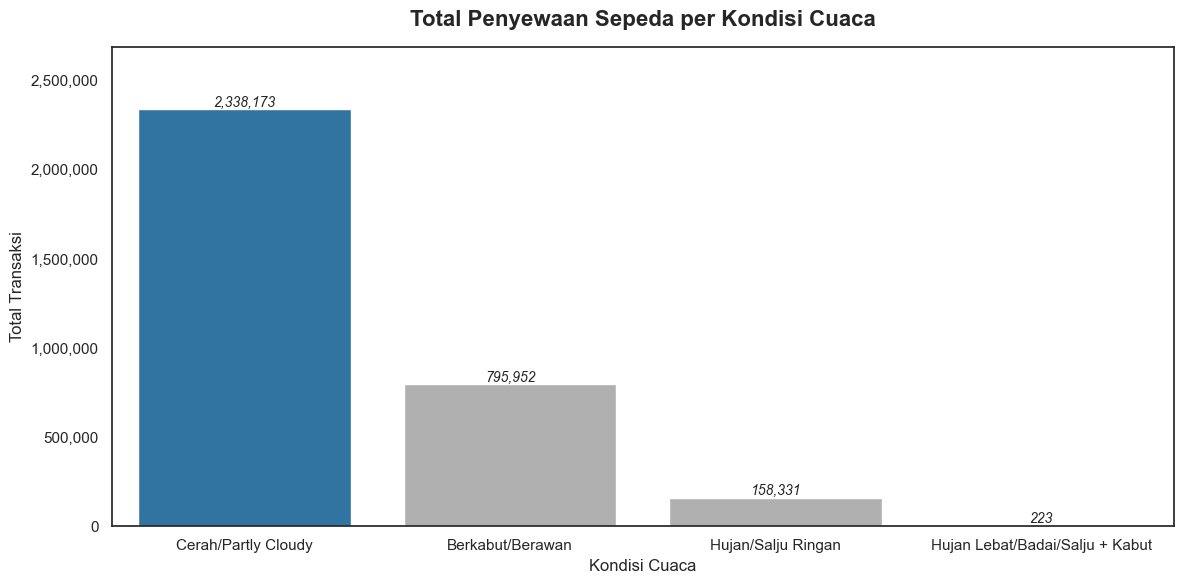

In [37]:
# ── 1. Agregasi ───────────────────────────────────────────────────────────────
weather_data = (
    df_clean
    .groupby("weathersit")
    .agg(sumcount=("cnt", "sum"))
    .reset_index()
    .sort_values("sumcount", ascending=False)
    .reset_index(drop=True)
)

# ── 2. Warna ──────────────────────────────────────────────────────────────────
weather_data["color"] = ["#1f77b4"] + ["#b0b0b0"] * (len(weather_data) - 1)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=weather_data, x="weathersit", y="sumcount", palette=weather_data["color"].tolist(), ax=ax)

for idx, row in weather_data.iterrows():
    ax.text(idx, row["sumcount"] + 2, f"{row['sumcount']:,.0f}",
            ha="center", va="bottom", fontsize=10, fontstyle="italic")

ax.set_title("Total Penyewaan Sepeda per Kondisi Cuaca", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Kondisi Cuaca", fontsize=12)
ax.set_ylabel("Total Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, weather_data["sumcount"].max() * 1.15)
ax.grid(False)

plt.tight_layout()
plt.show()

Berdasarkan data dari grafik "Total Penyewaan Sepeda per Kondisi Cuaca", berikut adalah analisisnya:

**Insight**

* Kondisi **Cerah/Partly Cloudy** merupakan penyumbang transaksi terbesar dengan total **2.338.173** penyewaan.
* Terdapat penurunan drastis saat cuaca berubah menjadi **Berkabut/Berawan**, dengan total transaksi sebesar **795.952**.
* Pada kondisi **Hujan/Salju Ringan**, jumlah penyewaan menurun signifikan menjadi **158.331** transaksi.
* Kondisi **Hujan Lebat/Badai/Salju + Kabut** memiliki jumlah transaksi yang hampir nihil, yaitu hanya **223** transaksi.

**Analisis**

* **Sensitivitas Cuaca:** Pengguna sangat mengutamakan kenyamanan dan keamanan, sehingga cuaca cerah menjadi pendorong utama volume transaksi.
* **Aktivitas Outdoor:** Karena bersepeda adalah kegiatan luar ruangan, kondisi awan dan kabut langsung menurunkan minat pengguna hingga kurang dari sepertiga dibandingkan saat cuaca cerah.
* **Faktor Risiko:** Penurunan tajam pada kondisi hujan ringan hingga badai menunjukkan bahwa sepeda tidak dianggap sebagai moda transportasi yang ideal atau aman saat cuaca buruk.
* **Ketergantungan Operasional:** Bisnis ini memiliki ketergantungan yang sangat tinggi pada faktor eksternal (iklim/cuaca), yang berarti pendapatan akan sangat fluktuatif tergantung musim.

**Rekomendasi**

* **Promosi Cuaca Mendung:** Berikan diskon khusus atau insentif "Cloudy Deals" saat cuaca berkabut atau berawan untuk menjaga volume transaksi agar tidak turun terlalu tajam.
* **Fasilitas Pelindung:** Pertimbangkan untuk menyediakan atau menjual perlengkapan tambahan seperti jas hujan *branded* di stasiun penyewaan untuk mengakomodasi pengguna saat hujan ringan.
* **Penjadwalan Perawatan Besar:** Lakukan *maintenance* besar-besaran pada armada saat prediksi cuaca menunjukkan hujan lebat atau badai, karena pada saat itu permintaan berada di titik terendah (hanya 223 transaksi).
* **Notifikasi Real-time:** Integrasikan fitur ramalan cuaca pada aplikasi penyewaan untuk memberikan saran waktu terbaik bersepeda kepada pengguna.

**Kesimpulan**

* Cuaca cerah adalah kontributor utama pendapatan bisnis penyewaan sepeda ini.
* Terdapat korelasi negatif yang sangat kuat antara tingkat keparahan cuaca dengan jumlah penyewaan.
* Strategi keberlanjutan bisnis memerlukan diversifikasi promo atau peningkatan fasilitas agar penggunaan tetap terjaga meski kondisi cuaca kurang optimal.

## Analisis Lanjutan : Clustering

Kita akan menggunakan fitur **temp, hum, dan windspeed** untuk proses clustering. Pemilihan ketiga variabel ini bertujuan untuk mengelompokkan data berdasarkan kombinasi kondisi cuaca, sehingga pola alami yang tersembunyi dalam data dapat terlihat lebih jelas. Dengan pendekatan ini, analisis tidak hanya melihat satu variabel secara terpisah, tetapi memahami bagaimana suhu, kelembaban, dan kecepatan angin saling berinteraksi dalam memengaruhi perilaku penyewaan sepeda.

Melalui clustering, kita dapat mengidentifikasi segmen kondisi cuaca tertentu yang memiliki karakteristik permintaan berbeda. Hasilnya diharapkan mampu memberikan insight tambahan terkait kondisi optimal maupun tidak optimal bagi bisnis, serta memperkuat temuan sebelumnya bahwa faktor cuaca—terutama suhu—memiliki pengaruh signifikan terhadap volume penyewaan.


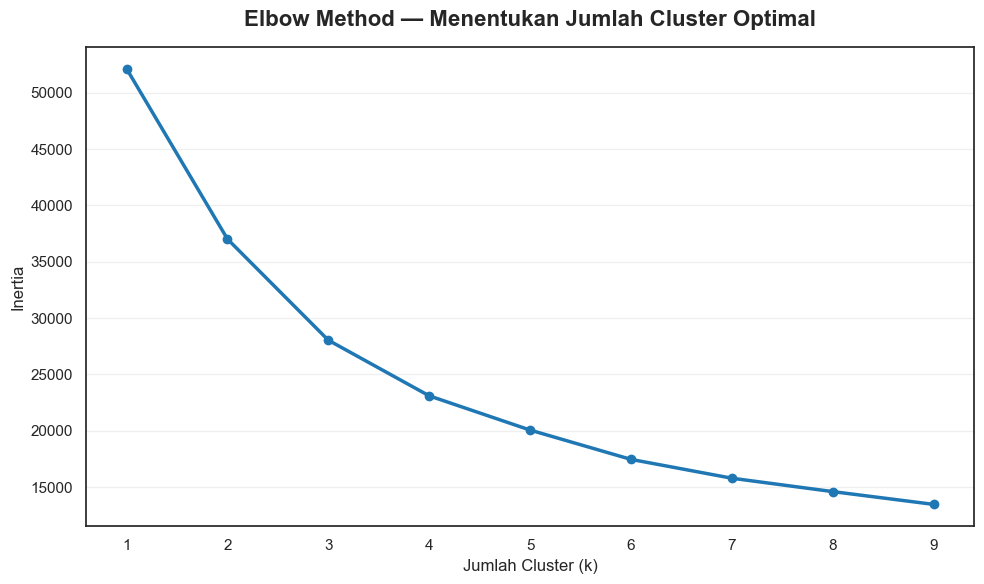

In [38]:
# ── 1. Persiapan Data ─────────────────────────────────────────────────────────
features = ["temp", "hum", "windspeed"]
X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 2. Elbow Method ───────────────────────────────────────────────────────────
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_range, inertia, marker="o", color="#1f77b4", linewidth=2.5)

ax.set_title("Elbow Method — Menentukan Jumlah Cluster Optimal", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Jumlah Cluster (k)", fontsize=12)
ax.set_ylabel("Inertia", fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Karakteristik Klaster (Satuan Asli):
   cluster  avg_temp_celsius  avg_humidity_pct  avg_windspeed_kmh  \
0        2             29.18             49.10              12.58   
1        0             22.87             82.03              10.01   
2        3             15.81             47.40              23.15   
3        1             12.07             64.02               7.95   

   total_rentals  
0        1373350  
1         802929  
2         623059  
3         493341  


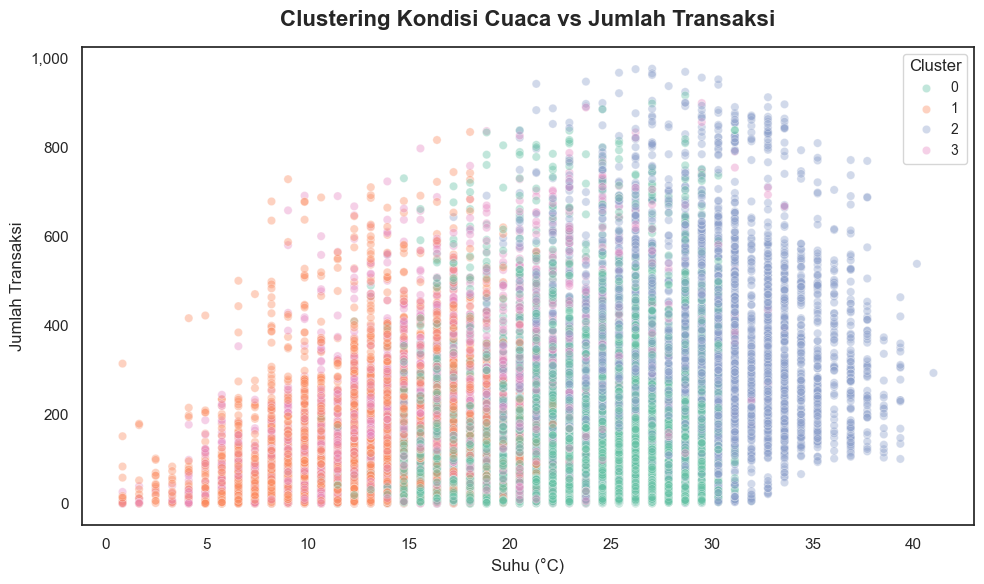

In [39]:
# ── 1. KMeans ─────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

# ── 2. Ringkasan per Cluster ──────────────────────────────────────────────────
cluster_insight = (
    df_clean.groupby("cluster")
    .agg(temp=("temp", "mean"), hum=("hum", "mean"),
         windspeed=("windspeed", "mean"), cnt=("cnt", "sum"))
    .reset_index()
)

cluster_insight.rename(columns={
    "temp": "avg_temp_celsius",
    "hum": "avg_humidity_pct",
    "windspeed": "avg_windspeed_kmh",
    "cnt": "total_rentals"
}, inplace=True)

cluster_insight = cluster_insight.sort_values("total_rentals", ascending=False).reset_index(drop=True)

print("Karakteristik Klaster (Satuan Asli):")
print(cluster_insight.round(2))

# ── 3. Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_clean, x="temp", y="cnt",
    hue="cluster", palette="Set2",
    alpha=0.4, ax=ax
)

ax.set_title("Clustering Kondisi Cuaca vs Jumlah Transaksi", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Suhu (°C)", fontsize=12)
ax.set_ylabel("Jumlah Transaksi", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Cluster", fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

**Insight**
- Terbentuk 4 segmen kondisi cuaca dengan volume penyewaan yang sangat berbeda
- Cluster 2 (suhu ~29°C, kelembaban ~49%) mendominasi dengan **1.37 juta transaksi**
- Cluster 1 (suhu ~12°C, kelembaban ~64%) menghasilkan transaksi paling rendah **493 ribu**
- Pola konsisten: semakin hangat dan semakin rendah kelembaban → semakin tinggi volume penyewaan



**Analisis**
- **Cluster 2** — kombinasi suhu hangat, kelembaban sedang, angin normal adalah kondisi paling ideal bagi pengguna
- **Cluster 0** — meski suhu nyaman ~23°C, kelembaban ekstrem ~82% menekan transaksi hampir separuh Cluster 2
- **Cluster 3** — kombinasi suhu dingin ~16°C dan angin kencang ~23 km/j cukup signifikan mengurangi minat bersepeda
- **Cluster 1** — suhu paling dingin ~12°C dengan kelembaban tinggi menjadi skenario terburuk bagi bisnis



**Rekomendasi**
- **Cluster 2** → siapkan armada penuh, tambah staf operasional, jalankan promosi aktif — ini adalah *window of opportunity* tertinggi
- **Cluster 0** → tawarkan diskon atau promo khusus untuk mendorong pengguna tetap menyewa saat kelembaban tinggi
- **Cluster 1 & 3** → kurangi unit yang dioperasikan, alihkan biaya ke maintenance armada untuk efisiensi bisnis



**Kesimpulan**
- Suhu adalah faktor dominan penyewaan sepeda, namun kelembaban dan kecepatan angin turut memoderasi perilaku pengguna
- Cluster terbaik menghasilkan hampir **3x lipat** transaksi dibanding cluster terdingin
- Strategi operasional berbasis kondisi cuaca bukan sekadar opsional — melainkan **krusial** untuk memaksimalkan revenue dan efisiensi bisnis

## Conclusion

**KESIMPULAN**

Berdasarkan hasil analisis data transaksi penyewaan sepeda, dapat disimpulkan bahwa model bisnis sangat bergantung pada pengguna terdaftar (registered) dengan kontribusi sebesar 81% dari total 3.292.679 transaksi. Hal ini menunjukkan tingkat loyalitas yang tinggi serta ketergantungan pendapatan terhadap segmen member.

Segmen pengguna casual (±19%) meskipun lebih kecil secara proporsi, memiliki potensi signifikan sebagai sumber pertumbuhan melalui strategi konversi menjadi member terdaftar. Pola musiman terlihat jelas, di mana musim hangat (Gugur dan Panas) menghasilkan volume transaksi tertinggi, sedangkan musim dingin dan semi mengalami penurunan.

Dari sisi temporal, transaksi didominasi hari kerja khususnya Kamis–Jumat, serta jam sibuk pagi (08.00) dan sore (17.00–18.00). Hal ini mengindikasikan bahwa sepeda lebih banyak digunakan untuk kebutuhan commuting dibandingkan rekreasi.

Faktor cuaca memiliki pengaruh signifikan terhadap volume transaksi. Kondisi cerah atau partly cloudy mendominasi penggunaan, sementara hujan dan kelembaban tinggi menyebabkan penurunan drastis. Analisis clustering menunjukkan bahwa kombinasi suhu hangat dan kelembaban sedang menghasilkan volume tertinggi, sedangkan suhu dingin dengan kelembaban tinggi menjadi kondisi terendah. Dengan demikian, performa bisnis sangat sensitif terhadap variabel musiman dan kondisi lingkungan.

Secara keseluruhan, optimalisasi strategi berbasis segmentasi pengguna, musim, waktu, dan cuaca menjadi faktor kunci dalam menjaga stabilitas dan pertumbuhan bisnis.

---

**REKOMENDASI**

**1. Strategi Retensi – Registered User**

Untuk mempertahankan kontribusi utama dari pengguna terdaftar:

* Implementasi program loyalitas (misalnya free ride setelah sejumlah perjalanan tertentu).
* Pemberian promo eksklusif dan early access pada periode high season.
* Pengembangan paket membership tahunan dengan skema harga lebih ekonomis.
* Pengiriman reminder otomatis untuk menjaga frekuensi penggunaan.
* Optimalisasi engagement pada musim puncak agar tingkat penggunaan tetap tinggi.

**2. Strategi Konversi – Casual User**

Untuk meningkatkan pertumbuhan melalui konversi:

* Menyediakan trial membership 7–14 hari.
* Memberikan diskon upgrade setelah 3–5 transaksi.
* Menampilkan simulasi potensi penghematan apabila menjadi member.
* Menargetkan kampanye konversi menjelang peak season untuk memaksimalkan probabilitas upgrade.

**3. Strategi Musiman dan Waktu**

High Season (Maret–Oktober / Gugur & Panas):

* Maksimalkan ketersediaan armada.
* Tingkatkan aktivitas promosi dan kampanye membership.
* Fokus pada ekspansi volume transaksi.

Low Season (November–Februari / Dingin & Semi):

* Fokus pada retensi dan stabilisasi pendapatan.
* Jalankan promo ringan untuk menjaga utilisasi.
* Lakukan preventive maintenance pada armada.

Optimalisasi Peak Hours:

* Distribusi sepeda optimal di area pemukiman saat pagi.
* Redistribusi ke area perkantoran menjelang sore.
* Monitoring real-time untuk menghindari kekosongan stok di titik strategis.

**4. Strategi Berbasis Cuaca dan Cluster**

* Pada kondisi ideal (hangat + kelembaban sedang), siapkan armada penuh dan jalankan kampanye aktif.
* Pada kondisi ekstrem (dingin, kelembaban tinggi, hujan), kurangi distribusi armada dan optimalkan jadwal maintenance.
* Integrasikan sistem notifikasi cuaca real-time dalam aplikasi.
* Tawarkan add-on perlengkapan (misalnya jas hujan) untuk memitigasi penurunan transaksi saat cuaca kurang ideal.

**5. Strategi Bisnis Makro**

* Menjaga keseimbangan antara retensi member loyal dan konversi pengguna baru.
* Mengoptimalkan momentum high season untuk pertumbuhan revenue.
* Menggunakan low season sebagai fase stabilisasi dan efisiensi operasional.
* Menerapkan pendekatan data-driven berbasis musim, waktu, dan cuaca sebagai dasar pengambilan keputusan strategis.

